# Collective motion across group size with golden shiners

The notebook is in two halves, deliberately separated.

**Part A runs everything with mosaic**: a track converter for a format mosaic
does not ship -- SchoolTracker's `_fov.h5` files -- written inside this notebook,
then conversion and one feature run over all ten trials. It ends with results on
disk and nothing else.

**Part B loads those results and plots them.** It is ordinary pandas and
matplotlib, and it opens the outputs from their path rather than from a variable
Part A left behind. The split is the point: everything mosaic contributes happens
in Part A, and anyone can see where that ends.

If your own tracking output is in some other format, Part A is the part to copy.
[Adding a converter](../docs/guides/tracking/write-a-converter.md) has the full contract.

## Getting the data: two ways

`SOURCE` in the next cell picks one.

**`"download"` (the default)** fetches the converted tables from
[EcodylicScience/mosaic-example-shiners][card] on Hugging Face -- 350 MB --
together with a 9 MB raw sample of one trial. Every cell below
still runs: the sample is a real SchoolTracker file, the converter written in
section 3 is executed on it, and its output is checked against the shipped table
before the analysis begins. So the conversion is demonstrated rather than
described, without the 45 GB.

**`"convert"`** builds the tables from the full Dryad download. That is the path
to copy for your own recordings, and the only one that reproduces every table
from scratch.

Either way sections 6 and 7 analyse all ten trials.

[card]: https://huggingface.co/datasets/EcodylicScience/mosaic-example-shiners

## The data

Free-swimming golden shiners (*Notemigonus crysoleucas*) in a 2.1 x 1.2 m tank,
filmed from above, tracked with SchoolTracker and manually identity-corrected.
Ten trials at four group sizes, 239,246 frames in all:

| group | trials | frames each | individuals |
| --- | --- | --- | --- |
| `10-fish` | 0066, 0105, 0126 | ~24,600 | 10 |
| `30-fish` | 0084, 0115, 0120 | ~24,580 | 30 |
| `70-fish` | 0103, 0107, 0124 | ~24,570 | 70 |
| `150-fish` | one trial | 17,999 | **151** |

The last row is not a typo: the directory is named `150-fish` and the file actually
reports 151 tracks. This notebook keeps the directory's name and prints the
measured count beside it, rather than quietly correcting one to the other.

**One thing to carry forward:** in these tables `X` / `Y` is the fish's **head**,
not its body centre. Every other tracker mosaic converts reports a centroid.
Section 2 says why, and section 4 writes the warning into the dataset's own
`notes:`, which is where it survives being handed to someone else.

**Citation.** Davidson JD, Sosna MMG, Twomey CR, Sridhar VH, Leblanc SP, Couzin ID
(2021) Collective detection based on visual information in animal groups.
*Journal of the Royal Society Interface* 18: 20210142.
[doi:10.1098/rsif.2021.0142](https://doi.org/10.1098/rsif.2021.0142)

**Data licence.** CC0 1.0, from Dryad:
[doi:10.5061/dryad.sbcc2fr2h](https://doi.org/10.5061/dryad.sbcc2fr2h). The
converted tables on Hugging Face are a derivative of that record and carry the
same licence. Every number and figure below is computed from the real recordings.

Against `getgroupstate` from the reference implementation that accompanies the
paper, run over the Dryad `pklz` trees this notebook does not download, mosaic's
per-frame collective state agrees on **100.00% of all 239,246 frames**, every
trial. That comparison needs data outside this example, so it is reported here
rather than computed below.

---

# Part A -- run it with mosaic

## Before you run: work on a copy

This notebook is tracked in the mosaic repository. Running it in place rewrites a
tracked file -- its outputs and execution counts -- and `git pull` will then refuse to
update it. Copy it out and run the copy:

```bash
mkdir -p ~/mosaic-examples
cp notebooks/collective-motion-shiners.ipynb ~/mosaic-examples/
```

The data unpacks to `~/mosaic-examples/shiners-example/` either way, so a copy run from anywhere
reuses the same download. Set `DOWNLOAD_DIR` below to point somewhere else.

In [1]:
import shutil
import tarfile
from pathlib import Path
from typing import Optional

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- configuration ---------------------------------------------------------
# Where the tracks come from.
#
#   "download" -- fetch the converted tables from Hugging Face (~370 MB), plus a
#                 small raw sample so every cell below still runs against a real
#                 SchoolTracker file. This is what most people want.
#   "convert"  -- build the tables yourself from the full Dryad download. Set
#                 DATA_DIR to the unpacked tree; it is 45 GB of *_fov.h5.
#
# The converter is written out and executed in both modes. In "download" it runs
# on the sample and its output is checked against the table that was shipped, so
# nothing below is taken on trust.
SOURCE = "download"

# -- download mode --
HF_REPO = "EcodylicScience/mosaic-example-shiners"
# Where the downloaded dataset is unpacked. None -> ~/mosaic-examples/shiners-example
DOWNLOAD_DIR: Optional[Path] = None

# -- convert mode --
# The unpacked CollectiveDetection_Shiners_Data tree.
DATA_DIR: Optional[Path] = None
# Where the mosaic dataset is built. Conversion is the expensive step and its
# results are cached, so this wants to be somewhere that survives the session --
# a second run of this notebook should be a cache hit, not a second conversion.
PROJECT_DIR: Optional[Path] = None

# Restrict the analysis to some entries, as (group, sequence) pairs. None -> all.
TRIALS: Optional[list[tuple[str, str]]] = None

FPS = 29.97
GROUPS = ["10-fish", "30-fish", "70-fish", "150-fish"]

# ---- resolve the two paths every later cell uses ---------------------------
# SRC     -- a tree of *_fov.h5 to read and convert (one trial, or all ten)
# PROJECT -- the mosaic dataset the analysis reads
if SOURCE == "download":
    try:
        from huggingface_hub import hf_hub_download
    except ImportError as exc:  # pragma: no cover - environment guidance
        raise ImportError(
            "SOURCE='download' needs huggingface_hub:\n"
            "    pip install 'huggingface_hub>=1.2.0'\n"
            "The version floor matters: older clients retry a rate-limit "
            "response with a 25-second backoff against a 5-minute window, so "
            "they fail rather than wait. Set SOURCE='convert' to skip the "
            "download entirely and build from the Dryad tree."
        ) from exc

    root = Path(DOWNLOAD_DIR) if DOWNLOAD_DIR else Path.home() / "mosaic-examples" / "shiners-example"
    root.mkdir(parents=True, exist_ok=True)
    for asset, target in (
        ("shiners-tracks.tar.gz", "shiners-tracks"),
        ("shiners-raw-sample.tar.gz", "shiners-raw-sample"),
    ):
        if (root / target).exists():
            print(f"have      {root / target}")
            continue
        print(f"fetching  {asset} ...")
        archive = hf_hub_download(HF_REPO, asset, repo_type="dataset")
        with tarfile.open(archive) as tar:
            tar.extractall(root, filter="data")
    SRC = root / "shiners-raw-sample"
    PROJECT = root / "shiners-tracks"

elif SOURCE == "convert":
    if DATA_DIR is None:
        raise ValueError(
            "SOURCE='convert' needs DATA_DIR set to the unpacked "
            "CollectiveDetection_Shiners_Data tree.\n"
            "\n"
            "The data is CC0 1.0 and comes from Dryad, doi:10.5061/dryad.sbcc2fr2h\n"
            "  https://doi.org/10.5061/dryad.sbcc2fr2h\n"
            "\n"
            "The whole record is 32 GB across 11 zips; unpacked, the *_fov.h5\n"
            "files this notebook reads come to about 45 GB.\n"
            "\n"
            "Set SOURCE='download' instead to fetch the converted tables (370 MB)\n"
            "with a raw sample, which runs every cell below without the 45 GB."
        )
    SRC = Path(DATA_DIR)
    PROJECT = Path(PROJECT_DIR) if PROJECT_DIR else SRC.parent / "shiners_mosaic"

else:
    raise ValueError(f"SOURCE must be 'download' or 'convert', not {SOURCE!r}")

# Staging lives inside the project rather than in a temporary directory, so the
# symlinks the index was built from are still there on a later run. It is
# rebuilt from empty each time, so it always matches what is on disk now.
STAGED = PROJECT / "_staged"
if STAGED.exists():
    shutil.rmtree(STAGED)

print(f"mode      {SOURCE}")
print(f"reading   {SRC}")
print(f"dataset   {PROJECT}")


def discover_trials(root):
    """`(group, trial, [segments])` for every trial under *root*.

    Nine trials are stored as `<group>/<trial>/<trial>_NNN_fov.h5`. The 150-fish
    trial is a single loose file in `<group>/`, so a rule that assumed a trial
    directory would miss it entirely. Both layouts are handled here, once, and
    everything downstream reads the result.
    """
    out = []
    for group in GROUPS:
        group_dir = root / group
        if not group_dir.exists():
            continue
        for trial_dir in sorted(d for d in group_dir.iterdir() if d.is_dir()):
            segments = sorted(
                p for p in trial_dir.glob("*_fov.h5") if not p.name.startswith("._")
            )
            if segments:
                out.append((group, trial_dir.name, segments))
        loose = sorted(
            p for p in group_dir.glob("*_fov.h5") if not p.name.startswith("._")
        )
        if loose:
            out.append((group, group, loose))
    return out


TRIAL_FILES = discover_trials(SRC)
print(
    f"\n{len(TRIAL_FILES)} trial(s) of raw *_fov.h5, "
    f"{sum(len(s) for _, _, s in TRIAL_FILES)} segment files"
)
for group, trial, segments in TRIAL_FILES:
    print(f"   {group:10s} {trial:10s} {len(segments)} segment(s)")
if SOURCE == "download":
    print(
        "\nThat is the sample. The converted tables for all ten trials came "
        "down with it;\nsections 1-5 work through the sample, section 6 "
        "analyses all ten."
    )

have      /private/tmp/mosaic-examples/shiners-example/shiners-tracks
have      /private/tmp/mosaic-examples/shiners-example/shiners-raw-sample
mode      download
reading   /private/tmp/mosaic-examples/shiners-example/shiners-raw-sample
dataset   /private/tmp/mosaic-examples/shiners-example/shiners-tracks

1 trial(s) of raw *_fov.h5, 7 segment files
   10-fish    0066       7 segment(s)

That is the sample. The converted tables for all ten trials came down with it;
sections 1-5 work through the sample, section 6 analyses all ten.


## 1. What is in the file

Each segment is one HDF5 file: two root attributes and a flat `fields` group,
every array **individual-major** -- `(n_tracks, n_frames)` or
`(n_tracks, n_frames, n_points)`.

The tables below describe the **full Dryad file**, which carries 32 arrays. The
sample `SOURCE="download"` fetches has been reduced to the six the converter
actually reads -- `x`, `y`, `heading_x`, `heading_y`, `body_length`, `detected` --
and those six are byte-identical to the originals. So open the sample with h5py and
expect six; the other twenty-six are described here because they are what you meet
in your own copy of the record.

| Field | What it is |
| --- | --- |
| `x`, `y` | the **head** position in video pixels, within 2 px of the eye midpoint |
| `heading_x`, `heading_y` | a **measured** body-axis unit vector, not a velocity direction |
| `body_length` | pixels; about 77 here |
| `left_eye_*`, `right_eye_*` | pixels |
| `detected` | validity mask; 1 everywhere in this dataset |

Three things are worth knowing before writing any converter against it, and none
of them are written down in the file.

**`x` / `y` is the head, and it is the only landmark measured in pixels.** It
sits within 2 px of the midpoint between the two eyes. Everything else that
describes body shape is either body-local or derived. This matters downstream:
most trackers report a **body centroid**, so a table built from this format is
not directly comparable to one built from TRex or SLEAP without accounting for
the offset. Section 2 registers the schema that names it, and section 4 records it
in the manifest.

**The heading is measured, not derived.** It comes from the body-axis fit and is
genuinely different from the direction of travel: a median of 3.5 degrees apart,
and more than 15 degrees apart on 15% of frames. Fish sideslip and glide, and
turn their bodies before their paths follow. Together with the head position it
is everything the collective-motion measurements below need.

**The 150-fish file is arranged differently.** It is a single file rather than
seven segments, it is shorter (17,999 frames), and it lacks the optional `date`,
`version`, `sobj_*` and `fov_*` fields the others carry. Everything the converter
reads is present, so it needs no special case for reading -- only for naming.

### What this converter deliberately leaves behind

The file carries more than the converter takes, and the reasons are worth stating
because "it was there and I did not use it" is a question every reader will ask.

| Field | Why it is not converted |
| --- | --- |
| `body_midline_x`, `_y` | A 21-point midline in a **body-local** frame: `x` is arc position in midline-segment units (1.0 to 21.0), `y` the lateral bend. Reaching pixels needs a scale, `body_length / span`, and that scale is not trustworthy -- see below. |
| `body_length` | Kept as a column, because the tracker measures it and a reader may want it. Not used to place anything. |
| `left_eye_*`, `right_eye_*` | Measured in pixels and perfectly usable, but they add nothing to a collective-motion analysis that already has a head and a heading. |
| `fov_distance`, `fov_identity` | The 256-ray visual field. A different analysis entirely, and the bulk of the 45 GB. |
| `body_curvature_*`, `body_spline`, `body_flank_*` | Shape descriptors in body-local units, with the same scale problem. |
| `sobj_*` | Stimulus-object fields, all zero in these trials. |

**On the midline specifically.** Turning it into pixels needs a scale factor,
`body_length / span`, and that factor is not reliable: `body_length` overshoots
the visible fish by roughly a factor of two, and nothing in the file records the
correction. Pose columns resting on an unresolved factor are worse than none --
they look like measurements. So this converter locates exactly one point, the
head, which is also what the published analysis of this dataset used. Because
that point is already what `X` / `Y` carries, no `poseX*` / `poseY*` columns are
written at all; section 2 explains why a copy would be worse than nothing.

In [2]:
print(
    f"{'group':10s} {'trial':10s} {'segs':>5s} {'frames':>8s} {'fish':>5s}  "
    f"{'undetected':>11s} {'|heading| range':>18s}"
)
for group, trial, segments in TRIAL_FILES:
    frames = fish = undetected = total = 0
    lo, hi = np.inf, -np.inf
    for p in segments:
        with h5py.File(p, "r") as f:
            frames += int(f.attrs["nframes"])
            fish = int(f.attrs["ntracks"])
            detected = f["fields/detected"][()]
            norm = np.hypot(f["fields/heading_x"][()], f["fields/heading_y"][()])
        undetected += int((detected == 0).sum())
        total += detected.size
        lo, hi = min(lo, norm.min()), max(hi, norm.max())
    print(
        f"{group:10s} {trial:10s} {len(segments):>5d} {frames:>8,} {fish:>5d}  "
        f"{100 * undetected / total:>10.3f}% {lo:>8.4f}-{hi:.4f}"
    )
print("\n|heading| of 1 means the tracker reports a unit body-axis vector, so no")
print("normalization is needed; 0% undetected means no missing-data handling either.")

group      trial       segs   frames  fish   undetected    |heading| range
10-fish    0066           7   24,578    10       0.000%   0.9998-1.0003

|heading| of 1 means the tracker reports a unit body-axis vector, so no
normalization is needed; 0% undetected means no missing-data handling either.


## 2. What mosaic asks a converter for

A converter turns one raw file into one standard table: per frame, per
individual, with `frame, time, id, group, sequence, X, Y`. Keypoints
(`poseX*` / `poseY*`) are **optional**. The `mosaic_v1` schema adds two rules
that decide this converter's design.

**Positions are video pixels, and `X`/`Y` is nominally the body centre.** This
converter puts the **head** there instead, because that is the only landmark the
format measures and the body centre cannot be placed without an unresolved scale.
That is a real deviation, so it is written into the schema description below and
into the converter's docstring rather than left implicit -- a reader comparing
these tables against a table whose `X` really is a centroid is comparing two
different landmarks, roughly half a body length apart, and nothing in the numbers
would say so.

**Be clear about how far that warning travels.** `tracks/index.csv` records the schema
*name*, `schooltracker_v1`, and nothing else about it. `TrackSchema.description` lives in
the registry of whichever process registered it, and mosaic never writes it to disk. So
the description below documents the choice for whoever reads this notebook; it is not a
label attached to the parquet. Section 4 puts the same sentence into `dataset.yaml`'s
`notes:`, which does travel with the dataset.

**Keypoints are optional, and this converter emits none.** The head is the one
point measured, and it is already in `X`/`Y`. Writing it a second time as
`poseX0`/`poseY0` would store a bit-identical copy under a name that promises a
separately detected landmark. Version 0.2 of this converter did exactly that; 0.3
stops, which costs nothing and saves 37% of the table. Features defined on
keypoints refuse a table without them, naming themselves; features that merely
prefer them (`egocentric-crop`, the overlay) fall back to `X`/`Y` -- the identical
value here.

**Derived quantities are forbidden.** `mosaic_v1` refuses fifteen columns --
`VX, VY, AX, AY, SPEED, ANGLE, ANGULAR_V, X#wcentroid` and their variants --
because each was, at some point, computed *by a converter* and then read
downstream as though the tracker had reported it. Velocity by `np.gradient`,
heading by a principal-component fit whose sign is arbitrary. The numbers look
plausible, so nothing downstream can tell a measurement from a guess. Those
belong to features, where the method is chosen and recorded.

`ANGLE` is on that list, and SchoolTracker genuinely measures it. That is what
`extends` and `allows` are for: a schema that is `mosaic_v1` in every other
respect and lifts exactly one column.

In [3]:
from mosaic.core.schema import (
    TRACK_SCHEMAS,
    TrackSchema,
    register_track_schema,
    schema_family,
)

register_track_schema(
    TrackSchema(
        name="schooltracker_v1",
        extends="mosaic_v1",
        allows={"ANGLE"},
        description=(
            "mosaic_v1 plus the body-axis heading SchoolTracker measures: ANGLE "
            "is a reported unit vector, not an inference from displacement. "
            "Nothing else in the derived set is allowed. "
            "WARNING -- X/Y IS THE FISH'S HEAD, NOT ITS BODY CENTRE. Every other "
            "tracker mosaic converts (TRex, SLEAP, Ultralytics, DeepLabCut) puts "
            "a body centroid in X/Y. SchoolTracker measures no centroid: it "
            "locates the head, within 2 px of the eye midpoint, and that is what "
            "X/Y holds here. The format's body-shape fields are body-local with "
            "no recorded scale, so no centroid can be placed. Do not compare X "
            "across this schema and a centroid-bearing one without accounting "
            "for the offset -- roughly half a body length, and recorded nowhere "
            "in the numbers. There are no poseX*/poseY* columns: the head is the "
            "one point measured and it is already in X/Y, so a keypoint pair "
            "would be a verbatim copy under a name promising a second landmark."
        ),
    )
)

s = TRACK_SCHEMAS["schooltracker_v1"]
print(
    "family         :",
    schema_family("schooltracker_v1"),
    "-> mixes with any mosaic_v1 table",
)
print(
    "keypoints      : none -- X/Y is the head, and mosaic_v1 makes poseX*/poseY* optional"
)

family         : mosaic_v1 -> mixes with any mosaic_v1 table
keypoints      : none -- X/Y is the head, and mosaic_v1 makes poseX*/poseY* optional


`allows` takes effect only together with `extends` -- it subtracts from the
forbidden set the base contributed. A schema declaring `forbidden=` and `allows=`
with no `extends` registers without complaint and still refuses the column.

Because this schema is registered in a notebook rather than inside mosaic, its
name is recorded in `tracks/index.csv` but is unknown to any other process.
Conversion has to happen here, which it does. Feature runs in a fresh process are
fine; `mosaic convert-tracks` from the command line would not be. For a
self-contained analysis that is the right trade -- a converter used across a team
belongs in a module everyone imports.

## 3. The converter

In [4]:
from scipy.optimize import linear_sum_assignment

from mosaic.core.track_converter import (
    EntryHints,
    TrackConverter,
    TrackConvertParams,
    register_track_converter,
)


class SchoolTrackerParams(TrackConvertParams):
    """Everything that determines the output, and nothing else.

    Entry identity travels in `EntryHints`, never here: params are hashed into
    the tracks variant id, so a sequence name in params would mint one variant
    per file where there is one recipe.
    """

    fps: float = 29.97
    drop_undetected: bool = True


@register_track_converter
class SchoolTrackerConverter(TrackConverter[SchoolTrackerParams]):
    """SchoolTracker `_fov.h5` -> a `schooltracker_v1` table.

    **`X` / `Y` is the fish's HEAD, not its body centre.** Read that before
    comparing these tables against any other tracker's. TRex, SLEAP, Ultralytics
    and every other converter mosaic ships put a **body centroid** in `X` / `Y`;
    this format measures no centroid at all. What it measures is a head position
    in pixels -- within 2 px of the midpoint between the two eyes -- and that is
    what lands in `X` / `Y` here. A feature that reads `X` across this table and
    a centroid-bearing one is comparing two different landmarks, and nothing in
    the numbers will say so. The schema description above carries the same
    warning; the copy that travels with the dataset is the one section 4 writes
    into ``dataset.yaml``'s ``notes:``.

    **No keypoint columns are emitted.** `mosaic_v1` makes `poseX*` / `poseY*`
    optional precisely so a tracker with one measured point need not invent a
    pair. Writing `poseX0 = X` would store a bit-identical copy of the head under
    a name promising a separately detected landmark -- 37% more bytes conveying
    nothing, and a fictional keypoint handed to anything that reads them. The
    features that fall back to the body centre when keypoints are absent
    (`egocentric-crop`, the overlay) land on the identical value either way.
    Section 1 explains why nothing further -- the midline, the eyes -- is
    reconstructed into pixels.

    `drop_undetected` is inert on this dataset: `detected` is 1 for every fish in
    every frame of all ten trials. It is kept because that is a property of this
    recording, not of the format.
    """

    src_format = "schooltracker_fov_h5"
    version = "0.3"  # 0.1 reconstructed a body centre from the body-local midline;
    # 0.2 emitted poseX0/poseY0 as a verbatim copy of X/Y
    enumerable = False  # no file holds more than one sequence
    merges_per_sequence = True  # ... but several files hold one between them
    output_schema = "schooltracker_v1"
    Params = SchoolTrackerParams

    def sequence_from_stem(self, stem: str) -> str:
        """`0066_003_fov` -> `0066`: the trial, not the segment.

        This is what makes the scan group a trial's files into one entry. It
        describes the format's naming, so it is not a `Params` field.
        """
        return stem.rsplit("_", 2)[0]

    def convert(self, path, params, hints):
        with h5py.File(path, "r") as f:
            n_frames = int(f.attrs["nframes"])
            n_tracks = int(f.attrs["ntracks"])
            read = lambda name: f[f"fields/{name}"][()]  # noqa: E731
            hx, hy = read("heading_x"), read("heading_y")
            head_x, head_y = read("x"), read("y")
            body_length = read("body_length")
            detected = read("detected")

        offset, canonical = self._segment_offsets(path, n_tracks)
        frames = offset + np.tile(np.arange(n_frames, dtype=np.int64), n_tracks)

        table = pd.DataFrame(
            {
                "frame": frames,
                "time": frames / params.fps,
                "id": np.repeat(canonical.astype(np.int64), n_frames),
                # the HEAD -- see the class docstring. Not a centroid.
                "X": head_x.reshape(-1),
                "Y": head_y.reshape(-1),
                "ANGLE": np.arctan2(hy, hx).reshape(-1),
                "body_length": body_length.reshape(-1),
                "group": np.full(frames.size, hints.group),
                "sequence": np.full(frames.size, hints.sequence),
            }
        )
        if params.drop_undetected:
            table = table[detected.reshape(-1) != 0].reset_index(drop=True)
        return table

    @staticmethod
    def _siblings(path):
        """This trial's segments, in recording order.

        The path handed in is the ORIGINAL file on the source volume, not the
        staged symlink -- mosaic resolves the link before recording it. So this
        globs the source tree, and it is correct only because that tree already
        gives each trial a directory holding only its own segments.
        """
        return sorted(
            p for p in path.parent.glob("*_fov.h5") if not p.name.startswith("._")
        )

    @staticmethod
    def _edge(path, index):
        """Every individual's position on one frame, as an (n, 2) array."""
        with h5py.File(path, "r") as f:
            return np.stack([f["fields/x"][:, index], f["fields/y"][:, index]], axis=-1)

    @classmethod
    def _segment_offsets(cls, path, n_tracks):
        """This segment's starting frame, and its track labels in trial terms.

        A trial's files are consecutive chunks of one recording, but each numbers
        its frames from zero and labels its tracks arbitrarily. Concatenating raw
        would give every individual a trajectory that teleports at each join.

        Frames are fixed by summing the earlier segments' `nframes`. Identity is
        fixed by matching each segment's first frame to the previous segment's
        last: across all 54 joins in this dataset the match sits at most 17 px
        away, and the MEDIAN next-best candidate is never closer than 4.7x the
        median match. Per individual it is looser than that -- 12 of 1980 pairs
        have a runner-up nearer than their own partner -- which is exactly the case
        a global assignment exists to settle: `linear_sum_assignment` optimizes the
        whole permutation, not each row greedily. The per-join permutations then
        compose forward onto the first segment's labels.

        This is the one place the converter opens a file other than the one it
        was handed, and it reads two columns per sibling, not the arrays.
        """
        siblings = cls._siblings(path)
        position = siblings.index(path)
        offset = 0
        canonical = np.arange(n_tracks)
        for earlier, later in zip(siblings[:position], siblings[1 : position + 1]):
            with h5py.File(earlier, "r") as f:
                offset += int(f.attrs["nframes"])
            cost = np.linalg.norm(
                cls._edge(later, 0)[:, None, :] - cls._edge(earlier, -1)[None, :, :],
                axis=-1,
            )
            rows, cols = linear_sum_assignment(cost)
            step = np.empty(n_tracks, dtype=int)
            step[rows] = cols
            canonical = canonical[step]
        return offset, canonical


print(
    "registered as:",
    SchoolTrackerConverter.src_format,
    "version",
    SchoolTrackerConverter.version,
)

registered as: schooltracker_fov_h5 version 0.3


## 4. Naming the entries

`group` is the group size and `sequence` is the trial, which is what makes
`10-fish` / `0066` a different entry from `70-fish` / `0103`.

mosaic keys an entry by the file's **stem**, and here the stems do not all
cooperate: nine trials are named `<trial>_<segment>_fov.h5`, but the 150-fish
trial is a single file called `fov_1-18000_2_fov.h5`, whose stem names no trial
at all. Rather than contort the naming rule around one file, the cell below
stages symlinks into a uniform layout -- `<group>/<sequence>/<sequence>_NNN_fov.h5`
-- and everything downstream reads the same rule. Symlinks, so nothing is copied.

Note what staging does **not** do. mosaic resolves a symlink before recording it,
so the converter is handed the original path on the source volume -- and
`_siblings` therefore globs the *original* trial directory, not `STAGED`. That
works here only because the source layout already gives each trial a directory of
its own. Section 7 says what to do when yours does not.

In [5]:
import tempfile

from mosaic.core.dataset import Dataset, new_dataset_manifest
from mosaic.core.manifest import default_roots
from mosaic.core.pipeline.tracks_index import read_tracks_index


def stage_segments(trial_files, staged_root):
    """Symlink every segment as `<group>/<sequence>/<sequence>_NNN_fov.h5`.

    One naming rule then covers both source layouts, and each trial's segments
    stay in a directory of their own -- which is how the converter finds a
    file's siblings. Returns where the joins fall, in merged frame numbers.
    """
    joins = {}
    for group, trial, segments in trial_files:
        lengths = []
        for n, seg in enumerate(segments):
            dest = staged_root / group / trial / f"{trial}_{n:03d}_fov.h5"
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():
                dest.symlink_to(seg.resolve())
            with h5py.File(seg, "r") as f:
                lengths.append(int(f.attrs["nframes"]))
        joins[(group, trial)] = list(np.cumsum(lengths)[:-1])
    return joins


def make_dataset(path, name):
    manifest = path / "dataset.yaml"
    return Dataset(
        manifest
        if manifest.exists()
        else new_dataset_manifest(name=name, base_dir=path, roots=dict(default_roots))
    ).load()


def convert_into(ds, staged_root, n_segments):
    """Index the staged tree and convert everything in it."""
    # A scan replaces the rows it claims and preserves everything else, so running
    # this twice is idempotent -- and the second run carries the previous pass's
    # checksums forward instead of re-hashing 45 GB of source.
    ds.index_tracks_raw(
        [staged_root],
        patterns="*_fov.h5",
        src_format="schooltracker_fov_h5",
        recursive=True,
        group_from_path=lambda p: p.parent.parent.name,  # the group-size directory
    )
    assert len(ds.read_tracks_raw_index()) == n_segments
    # Entries already converted under this recipe are skipped, so a second run
    # of this notebook against the same PROJECT costs nothing.
    outcome = ds.convert_all_tracks(params={"fps": FPS})
    assert outcome.failed == 0, "a trial failed to convert"
    return outcome


# The one place the head-vs-centroid warning can be attached to the DATA rather
# than to this notebook. `notes:` is free text on the manifest, so it travels with
# the dataset directory wherever it is copied -- unlike the schema description,
# which never leaves the registering process.
HEAD_WARNING = (
    "X/Y is the fish's HEAD, not its body centre. SchoolTracker measures no "
    "centroid: it locates the head, within 2 px of the eye midpoint. Every other "
    "tracker mosaic converts puts a body centroid in X/Y, so do not compare X "
    "across this dataset and a centroid-bearing one without applying the offset "
    "-- roughly half a body length, and recorded nowhere in the numbers."
)

JOINS = stage_segments(TRIAL_FILES, STAGED)
N_SEGMENTS = sum(len(s) for _, _, s in TRIAL_FILES)
print(f"staged {N_SEGMENTS} segments under {STAGED}")

ds = make_dataset(PROJECT, "shiners collective motion")

if SOURCE == "convert":
    print(convert_into(ds, STAGED, N_SEGMENTS))
else:
    # PROJECT already holds all ten converted tables. Run the converter above on
    # the raw sample into a scratch dataset and check it reproduces the shipped
    # table exactly -- so the converter printed in this notebook is demonstrably
    # the one that produced the data the rest of it reads, not a description of it.
    scratch = Path(tempfile.mkdtemp(prefix="shiners-verify-"))
    verify_ds = make_dataset(scratch, "shiners converter check")
    convert_into(verify_ds, STAGED, N_SEGMENTS)

    for group, trial, _ in TRIAL_FILES:
        ours = verify_ds.load_tracks(group, trial).reset_index(drop=True)
        shipped = ds.load_tracks(group, trial).reset_index(drop=True)
        pd.testing.assert_frame_equal(ours, shipped, check_exact=True)
        print(
            f"converter check: {group}/{trial} reproduces the shipped table "
            f"exactly ({len(ours):,} rows, {len(ours.columns)} columns)"
        )
    shutil.rmtree(scratch, ignore_errors=True)

if ds.notes != HEAD_WARNING:
    ds.set_notes(HEAD_WARNING)
print(f"dataset notes: {ds.notes[:60]}...\n")

index = read_tracks_index(ds)
print()
print(index[["group", "sequence", "n_rows"]].to_string(index=False))

# n_rows is stored as text -- a blank cell means "unknown", which is why it is
# not an int column. Summing it without the cast concatenates the digits.
total_rows = int(pd.to_numeric(index.n_rows, errors="coerce").fillna(0).sum())

non_finite = 0
for _, row in index.iterrows():
    table = ds.load_tracks(str(row["group"]), str(row["sequence"]))
    non_finite += int((~np.isfinite(table.X)).sum())
print(f"\nnon-finite positions: {non_finite} of {total_rows:,} rows")
print(
    f"keypoint columns: "
    f"{[c for c in table.columns if c.startswith(('poseX', 'poseY'))] or 'none'}"
    f"  -- X/Y is the head; see section 2"
)

staged 7 segments under /private/tmp/mosaic-examples/shiners-example/shiners-tracks/_staged
[index_tracks_raw] 7 -> /private/var/folders/sq/f41r2kzn2ngbwmv7p9lqfvp40000gp/T/shiners-verify-3abye2z_/tracks_raw/index.csv


converter check: 10-fish/0066 reproduces the shipped table exactly (245,780 rows, 9 columns)
dataset notes: X/Y is the fish's HEAD, not its body centre. SchoolTracker m...


   group sequence  n_rows
 10-fish     0066  245780
 10-fish     0105  245780
 10-fish     0126  246380
150-fish 150-fish 2717849
 30-fish     0084  737790
 30-fish     0115  737790
 30-fish     0120  736890
 70-fish     0103 1721510
 70-fish     0107 1720460
 70-fish     0124 1717310



non-finite positions: 0 of 10,827,539 rows
keypoint columns: none  -- X/Y is the head; see section 2


## 5. Inspect tracks to verify the converter

A converter that transposes an axis produces a table that passes every schema
check and is entirely wrong. Two cheap checks catch almost all of it: plot one
frame, and test the identity re-linking at the segment joins.

The identity test is the assignment's own margin. At each join, every individual
is matched to the previous segment's last frame, and what makes the match
trustworthy is not that the distance is small in absolute terms but that the
runner-up is far behind: a swap would put the matched distance on the same scale
as the spacing between fish. Below, the *median* matched partner sits a few pixels
away while the *median* next-best candidate is five to twenty times further, at
every join checked.

Read those as medians, not as bounds. A handful of individuals do have a runner-up
nearer than their own partner -- two fish crossing at the join -- and resolving that
is what a global assignment is for, so the table prints the worst per-individual
ratio beside the medians rather than only the comfortable number.

A jump in `X`/`Y` at the joins is the more obvious test, and it is weaker than it
looks. A few frames are dropped at each segment boundary, so a fish really has
moved further there than in one frame of ordinary swimming, and the step at a
join is legitimately two or three times the median. Distinguishing that from a
swap by step size alone means picking a threshold; the assignment margin needs
none.

1 of 10 trial(s) have raw segments here; the rest were converted elsewhere and shipped as tables.

group      sequence     matched px  next best px  margin  worst  ok
10-fish    0066        4.21/11.75  45.36         10.8x  2.22x  True


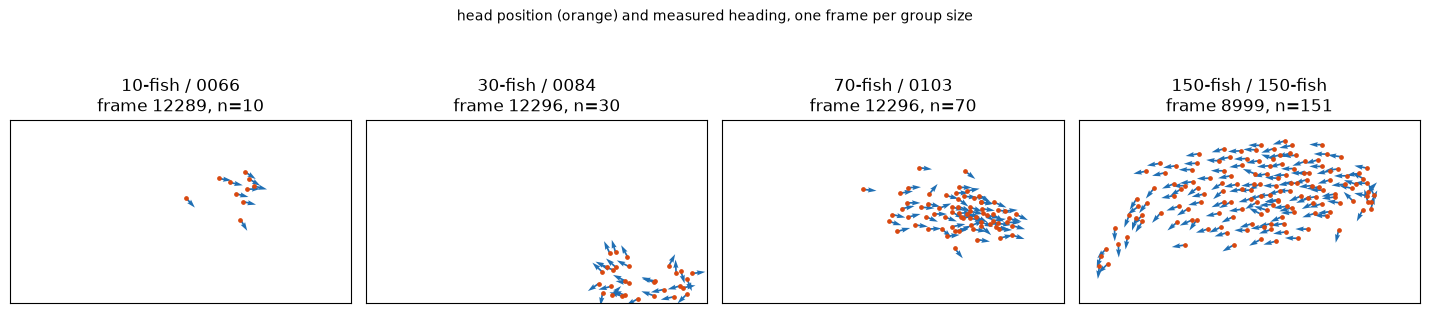

In [6]:
from scipy.optimize import linear_sum_assignment

entries = [(str(r["group"]), str(r["sequence"])) for _, r in index.iterrows()]
if TRIALS is not None:
    entries = [e for e in entries if e in TRIALS]

# The join test needs the raw segments, and in download mode only the sample trial
# was staged. Iterating the full index against a staging tree that holds one trial
# makes `glob` return nothing for the other nine, which reads as "one segment, no
# joins" -- a false statement about eight seven-segment recordings.
joinable = [e for e in entries if (STAGED / e[0] / e[1]).is_dir()]
print(f"{len(joinable)} of {len(entries)} trial(s) have raw segments here; "
      f"the rest were converted elsewhere and shipped as tables.\n")

print(
    f"{'group':10s} {'sequence':10s} {'matched px':>12s} {'next best px':>13s} "
    f"{'margin':>7s} {'worst':>6s}  ok"
)
for group, sequence in joinable:
    segments = sorted((STAGED / group / sequence).glob("*_fov.h5"))
    if len(segments) < 2:
        print(f"{group:10s} {sequence:10s} {'one segment, no joins':>34s}")
        continue
    matched, runner_up = [], []
    for earlier, later in zip(segments[:-1], segments[1:]):
        with h5py.File(earlier, "r") as f:
            last = np.stack([f["fields/x"][:, -1], f["fields/y"][:, -1]], axis=-1)
        with h5py.File(later, "r") as f:
            first = np.stack([f["fields/x"][:, 0], f["fields/y"][:, 0]], axis=-1)
        cost = np.linalg.norm(first[:, None, :] - last[None, :, :], axis=-1)
        rows, cols = linear_sum_assignment(cost)
        matched.append(cost[rows, cols])
        runner_up.append(np.array([np.delete(cost[i], cols[i]).min() for i in rows]))
    matched = np.concatenate(matched)
    runner_up = np.concatenate(runner_up)
    margin = np.median(runner_up) / np.median(matched)
    # The worst single individual, not the median: a ratio under 1 means someone
    # else's fish was nearer than this one's own partner. That is a crossing, and
    # resolving it is what the global assignment is for -- so it is worth seeing
    # rather than hiding behind a median.
    worst = float(np.min(runner_up / np.where(matched > 0, matched, np.nan)))
    ok = margin > 3.0
    print(
        f"{group:10s} {sequence:10s} {np.median(matched):5.2f}/{matched.max():5.2f} "
        f"{np.median(runner_up):6.2f}       {margin:>6.1f}x {worst:>5.2f}x  {ok}"
    )

fig, axes = plt.subplots(
    1,
    len(order_groups := [g for g in GROUPS if g in {e[0] for e in entries}]),
    figsize=(3.6 * len(order_groups), 3.9),
)
for ax, group in zip(np.atleast_1d(axes), order_groups):
    group_entry = next(e for e in entries if e[0] == group)
    tracks = ds.load_tracks(*group_entry)
    frame_no = int(tracks.frame.quantile(0.5, interpolation="nearest"))
    snapshot = tracks[tracks.frame == frame_no]
    ax.quiver(
        snapshot.X,
        snapshot.Y,
        np.cos(snapshot.ANGLE),
        np.sin(snapshot.ANGLE),
        angles="xy",
        scale=26,
        width=0.005,
        color="#1f6fb4",
    )
    ax.plot(snapshot.X, snapshot.Y, "o", ms=2.4, color="#d9480f")
    ax.set_aspect("equal")
    ax.invert_yaxis()  # image coordinates: +Y points down
    ax.set(
        title=f"{group} / {group_entry[1]}\nframe {frame_no}, n={len(snapshot)}",
        xlim=(0, 1920),
        ylim=(1032, 0),
        xticks=[],
        yticks=[],
    )
fig.suptitle(
    "head position (orange) and measured heading, one frame per group size", fontsize=10
)
fig.tight_layout()

## 6. Collective motion

Two order parameters, from Tunstrom et al. (2013). With `u_i` the unit heading of
individual `i` and `r_i` the unit vector from the group centroid to it:

- **polarization** `O_p = |mean(u_i)|` -- how aligned the group is, 0 to 1.
- **rotation** `O_r = |mean(u_i x r_i)|` -- how much it circles its own centre.

High polarization with low rotation is a **polarized** school; the reverse is a
**mill**; both low is a disordered **swarm**; anything else is **transitional**.

`heading_source="auto"` uses `ANGLE` where the table carries a usable one and
falls back to the direction of travel otherwise. Here it should resolve to
`orientation` for every entry -- and the output records which, so the choice is
auditable rather than assumed.

One caveat if you compare these numbers against the paper: its 0.35 / 0.65
thresholds were applied to a smoothed order-parameter series, and classifying
every raw frame puts noticeably more of them in `Transitional`. Per-frame
`O_p` and `O_r` have variance of order 1/N, which is large at ten fish. Smoothing
is a presentation choice about a series rather than part of the measurement, so
it is not done here; a `.rolling()` before plotting is all it takes.

In [7]:
from mosaic.behavior.feature_library.collective_motion_metrics import (
    CollectiveMotionMetrics,
)
from mosaic.core.scope import Scope

result = ds.run_feature(
    CollectiveMotionMetrics(params={"fps": FPS}),
    scope=Scope(entries=TRIALS),
)
print(result)

RESULTS_DIR = ds.get_root("features") / result.feature / result.run_id
check = pd.read_parquet(sorted(RESULTS_DIR.glob("*.parquet"))[0])
sources = check.heading_source.unique()
assert list(sources) == ["orientation"], f"expected measured headings, got {sources}"

print()
print("mosaic is done. Everything Part B needs is on disk:")
print(f"  tracks   {ds.get_root('tracks')}")
print(f"  results  {RESULTS_DIR}")
print(
    f"           {len(list(RESULTS_DIR.glob('*.parquet')))} parquet files, "
    f"one per entry"
)

[feature:collective-motion-metrics__from__tracks] completed run_id=0.1-bd10e629c5 -> /private/tmp/mosaic-examples/shiners-example/shiners-tracks/features/collective-motion-metrics__from__tracks/0.1-bd10e629c5
Result(feature='collective-motion-metrics__from__tracks', run_id='0.1-bd10e629c5', execution_id='01M0EQNQS8102PRCK1H0YK2KZ6', cache_hit=True, failed_entries=(), entries_written=10)

mosaic is done. Everything Part B needs is on disk:
  tracks   /private/tmp/mosaic-examples/shiners-example/shiners-tracks/tracks
  results  /private/tmp/mosaic-examples/shiners-example/shiners-tracks/features/collective-motion-metrics__from__tracks/0.1-bd10e629c5
           10 parquet files, one per entry


---

# Part B -- load the results and plot

Nothing below calls mosaic. It reads the parquet Part A wrote and draws figures
with pandas and matplotlib, the same as any other analysis would.

The only thing carried across the boundary is a path. `RESULTS_DIR` is
`features/<feature>/<run_id>/`, where `run_id` identifies the exact parameters
and inputs that produced it -- so quoting that path in a paper names a
reproducible computation, not just a folder.

In [8]:
# Everything this half needs, so it stands on its own: RESULTS_DIR and these.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results = pd.concat(
    [pd.read_parquet(p) for p in sorted(RESULTS_DIR.glob("*.parquet"))],
    ignore_index=True,
)

# Order the group sizes by the number of individuals actually in them, taken
# from the results rather than from a list written earlier.
order = results.groupby("group").n_ids.max().sort_values().index.tolist()

print(f"columns: {', '.join(results.columns)}")
results.groupby("group", sort=False)[
    ["n_ids", "polarization", "rotation"]
].mean().round(3)

columns: frame, time, n_ids, n_ids_heading, n_at_centroid, n_centroid_common, polarization, mean_heading, rotation, rotation_signed, group_angvel, state, centroid_x, centroid_y, centroid_speed, centroid_heading, sd_major, sd_minor, elongation, principal_axis_angle, area, density, heading_source, sequence, group


,n_ids,polarization,rotation
group,,,
10-fish,10.0,0.849,0.181
150-fish,151.0,0.590,0.362
30-fish,30.0,0.738,0.222
70-fish,70.0,0.552,0.331


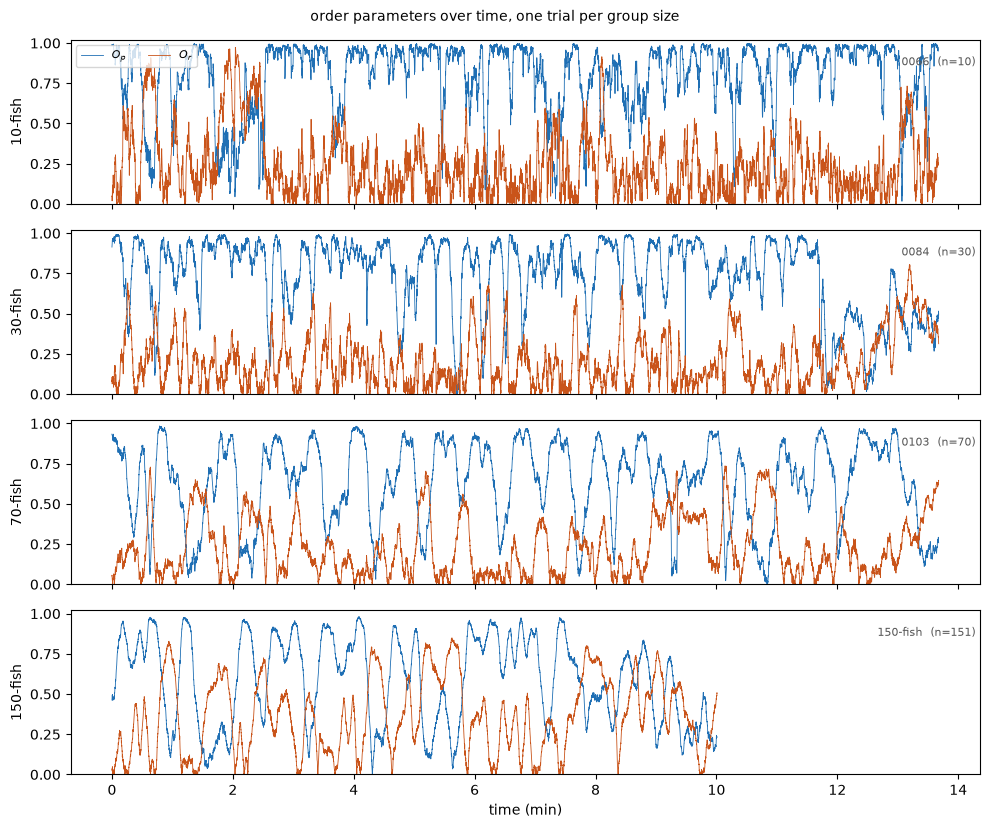

In [9]:
fig, axes = plt.subplots(len(order), 1, figsize=(10, 2.1 * len(order)), sharex=True)
for ax, group in zip(np.atleast_1d(axes), order):
    sub = results[results.group == group]
    first = sub.sequence.iloc[0]
    one = sub[sub.sequence == first].sort_values("time")
    ax.plot(one.time / 60, one.polarization, lw=0.6, color="#1f6fb4", label="$O_p$")
    ax.plot(one.time / 60, one.rotation, lw=0.6, color="#c9541a", label="$O_r$")
    ax.set(ylabel=group, ylim=(0, 1.02))
    ax.text(
        0.995,
        0.9,
        f"{first}  (n={int(one.n_ids.max())})",
        ha="right",
        va="top",
        transform=ax.transAxes,
        fontsize=8,
        color="#555",
    )
np.atleast_1d(axes)[0].legend(loc="upper left", ncols=2, fontsize=8)
np.atleast_1d(axes)[-1].set_xlabel("time (min)")
fig.suptitle("order parameters over time, one trial per group size", fontsize=10)
fig.tight_layout()

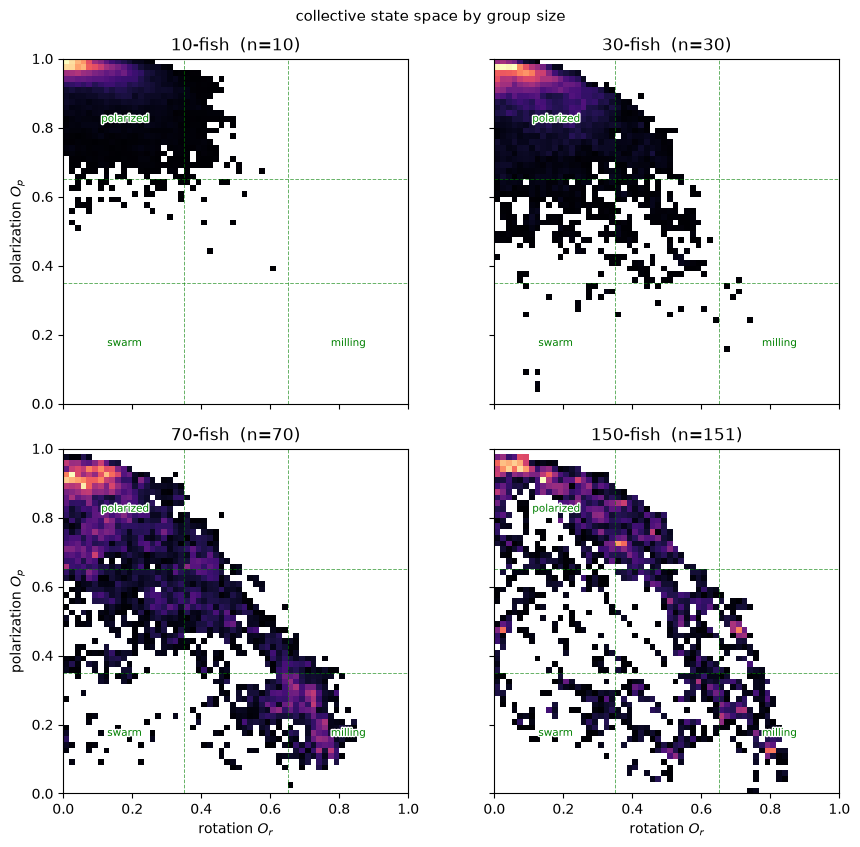

In [10]:
import matplotlib.patheffects as pe

STATE_HIGH, STATE_LOW = (0.65, 0.35)  # thresholds that define each discrete state

# Where each state sits, derived from the thresholds so the labels follow if
# those change. The classifier reads:
#   |O_r| < 0.35 and O_p < 0.35 -> swarm      |O_r| < 0.35 and O_p > 0.65 -> polarized
#   |O_r| > 0.65 and O_p < 0.35 -> milling    anything else               -> transitional
STATE_LABELS = [
    (STATE_LOW / 2, (1 + STATE_HIGH) / 2, "polarized"),
    (STATE_LOW / 2, STATE_LOW / 2, "swarm"),
    ((1 + STATE_HIGH) / 2, STATE_LOW / 2, "milling"),
]

n = len(order)
cols = 2 if n > 1 else 1
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.6 * cols, 4.3 * rows),
    squeeze=False,
    sharex=True,
    sharey=True,
)
for ax, group in zip(axes.ravel(), order):
    sub = results[results.group == group].dropna(subset=["rotation", "polarization"])
    h = ax.hist2d(
        sub.rotation,
        sub.polarization,
        bins=60,
        range=[[0, 1], [0, 1]],
        cmap="magma",
        cmin=1,
        density=True,
    )
    for level in (STATE_LOW, STATE_HIGH):
        ax.axhline(level, color="g", lw=0.7, ls="--", alpha=0.6)
        ax.axvline(level, color="g", lw=0.7, ls="--", alpha=0.6)
    for tx, ty, label in STATE_LABELS:
        ax.text(
            tx,
            ty,
            label,
            color="g",
            fontsize=7.5,
            ha="center",
            va="center",
            path_effects=[pe.withStroke(linewidth=2.0, foreground="white")],
        )
    ax.set(title=f"{group}  (n={int(sub.n_ids.max())})", aspect="equal")
for ax in axes.ravel()[n:]:
    ax.axis("off")
for ax in axes[-1]:
    ax.set_xlabel("rotation $O_r$")
for ax in axes[:, 0]:
    ax.set_ylabel("polarization $O_p$")
fig.suptitle("collective state space by group size", fontsize=11)
fig.tight_layout()

state,Polarized,Milling,Swarm,Transitional,Undefined
group,,,,,
10-fish,80.0,0.8,1.1,18.1,0.0
30-fish,64.1,1.7,3.8,30.4,0.0
70-fish,36.5,13.1,5.3,45.1,0.0
150-fish,36.2,10.2,5.9,47.8,0.0


tick marks are individual trials; 10/30/70-fish have three each, 150-fish one


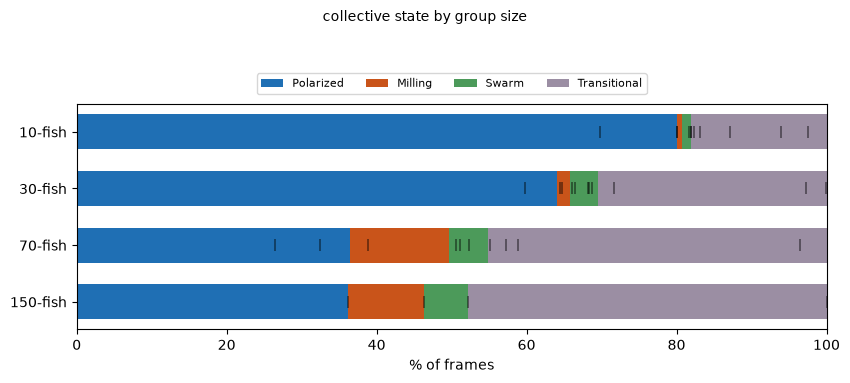

In [11]:
STATES = ["Polarized", "Milling", "Swarm", "Transitional", "Undefined"]
COLORS = {
    "Polarized": "#1f6fb4",
    "Milling": "#c9541a",
    "Swarm": "#4c9a5a",
    "Transitional": "#9b8ea3",
    "Undefined": "#cccccc",
}

by_group = (
    (
        results.groupby("group")
        .state.value_counts(normalize=True)
        .unstack(fill_value=0)
        * 100
    )
    .reindex(index=order)
    .reindex(columns=STATES)
    .fillna(0.0)
)
by_trial = (
    (
        results.groupby(["group", "sequence"])
        .state.value_counts(normalize=True)
        .unstack(fill_value=0)
        * 100
    )
    .reindex(columns=STATES)
    .fillna(0.0)
)

present = [s for s in STATES if by_group[s].sum() > 0.01]
fig, ax = plt.subplots(figsize=(8.6, 3.6))
left = np.zeros(len(order))
y = np.arange(len(order))
for state in present:
    ax.barh(
        y, by_group[state], left=left, color=COLORS[state], label=state, height=0.62
    )
    # per-trial points, so the unequal number of trials per group stays visible
    for i, group in enumerate(order):
        pts = by_trial.loc[group, state]
        ax.plot(
            left[i] + np.atleast_1d(pts),
            np.full(np.size(pts), y[i]),
            "|",
            color="k",
            ms=9,
            mew=1.1,
            alpha=0.55,
        )
    left += by_group[state].to_numpy()
ax.set(yticks=y, yticklabels=order, xlabel="% of frames", xlim=(0, 100))
ax.invert_yaxis()
ax.legend(
    ncols=len(present), fontsize=8, loc="lower center", bbox_to_anchor=(0.5, 1.02)
)
fig.suptitle("collective state by group size", y=1.05, fontsize=10)
fig.tight_layout()

display(by_group.round(1))
print("tick marks are individual trials; 10/30/70-fish have three each, 150-fish one")

## 7. Using this for your own data

Cells 2, 4 and the converter are format-specific. Everything from section 4
onwards is not -- it runs on any schema-valid track table, whatever produced it.

To adapt the converter, answer three questions:

1. **Does one file hold many sequences, or do many files make one sequence?**
   Set `enumerable = True` and implement `enumerate_sequences`, or
   `merges_per_sequence = True` and override `sequence_from_stem`. They are
   mutually exclusive. If files are several per sequence, check whether identity
   and frame numbering survive the joins -- here neither did, and both had to be
   repaired. And note where a converter that reads neighbouring files reads them:
   mosaic resolves a symlink before recording it, so your converter is handed the
   original path. Staging files into tidy per-trial directories does not change
   what `path.parent.glob(...)` sees. If your source is one flat directory, match
   siblings by filename rather than by directory, or copy rather than symlink.
2. **Does your tracker measure anything `mosaic_v1` forbids?** If it genuinely
   reports a heading or a speed, declare a schema that `extends="mosaic_v1"` and
   `allows` exactly that column. If it does not, emit `mosaic_v1` and let a
   feature derive it -- that is the honest answer, and the one that records how
   the derivation was done.
3. **Are your coordinates already video pixels?** `mosaic_v1` says they are. If
   yours are physical units or re-centred, convert in the converter and say so in
   its docstring, or the numbers will be wrong by a factor nobody recorded.

[Adding a converter](../docs/guides/tracking/write-a-converter.md) covers the full contract,
including how to ship a converter inside mosaic rather than in a notebook, and
what the registry tests then check for you.